# BigMart Sales Prediction
The dataset contains 8,523 training records and 5,681 test records. 

### Approach Overview
Before modelling, I started with a thorough EDA to understand what 
actually drives sales in retail.

## Step 1 — Install Dependencies



In [1]:
!pip install catboost -q
!pip install optuna -q


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Step 2 — Import Libraries

- `CatBoost` is chosen over XGBoost/LightGBM because of its native handling of categorical features — no manual encoding needed
- `optuna` is used to search the hyperparameter space much more efficiently than grid search
- used a fixed `RANDOM_SEED` and `SALES_YEAR=2013`. It ensures reproducibility and grounds the outlet age calculation in the correct reference year

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor, Pool
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
SALES_YEAR  = 2013   # Year of data collection per problem statement
N_FOLDS     = 5

## Step 3 — Load & Inspect the Data


In [3]:
train_path = '/Users/bujji/Documents/Mumbai/Case_analytics_vidhya_ABB/train_v9rqX0R.csv'
test_path  = '/Users/bujji/Documents/Mumbai/Case_analytics_vidhya_ABB/test_AbJTz2l.csv'

train_raw = pd.read_csv(train_path)
test_raw  = pd.read_csv(test_path)

print(f'Train shape : {train_raw.shape}')
print(f'Test shape  : {test_raw.shape}')
print(f'\nColumns: {train_raw.columns.tolist()}')
print(f'\nMissing in Train:\n{train_raw.isna().sum()[train_raw.isna().sum() > 0]}')
print(f'\nMissing in Test:\n{test_raw.isna().sum()[test_raw.isna().sum() > 0]}')
train_raw.head()

Train shape : (8523, 12)
Test shape  : (5681, 11)

Columns: ['Outlet_Identifier', 'Item_Identifier', 'Outlet_Location_Type', 'Outlet_Type', 'Outlet_Size', 'Outlet_Establishment_Year', 'Item_Type', 'Item_Fat_Content', 'Item_Weight', 'Item_Visibility', 'Item_MRP', 'Item_Outlet_Sales']

Missing in Train:
Outlet_Size    2410
Item_Weight    1463
dtype: int64

Missing in Test:
Outlet_Size    1606
Item_Weight     976
dtype: int64


,Outlet_Identifier,Item_Identifier,Outlet_Location_Type,Outlet_Type,Outlet_Size,Outlet_Establishment_Year,Item_Type,Item_Fat_Content,Item_Weight,Item_Visibility,Item_MRP,Item_Outlet_Sales
0,OUT049,FDA15,Tier 1,Supermarket Type1,Medium,1999,Dairy,Low Fat,9.30,0.016047,249.8092,3735.1380
1,OUT018,DRC01,Tier 3,Supermarket Type2,Medium,2009,Soft Drinks,Regular,5.92,0.019278,48.2692,443.4228
2,OUT049,FDN15,Tier 1,Supermarket Type1,Medium,1999,Meat,Low Fat,17.50,0.016760,141.6180,2097.2700
3,OUT010,FDX07,Tier 3,Grocery Store,NaN,1998,Fruits and Vegetables,Regular,19.20,0.000000,182.0950,732.3800
4,OUT013,NCD19,Tier 3,Supermarket Type1,High,1987,Household,Low Fat,8.93,0.000000,53.8614,994.7052


**Initial observations:**

- Two columns have missing values: `Outlet_Size` (~28%) and `Item_Weight` (~17%)
- Missing `Outlet_Size` is not random — it's missing for entire outlets
- Missing `Item_Weight` is SKU-level — the same item missing weight in one store will also miss it in others
- `Item_Visibility` has zeros which are physically impossible — a product on a shelf always has some visibility. These are effectively missing values

We have used these patterns for the imputation strategy.

## Step 4 — Exploratory Data Analysis


### 4.1 — Understanding the Target: Item Outlet Sales

Before doing anything else, I want to understand the shape of what I'm trying to predict. 
This determines whether I should transform the target before training.

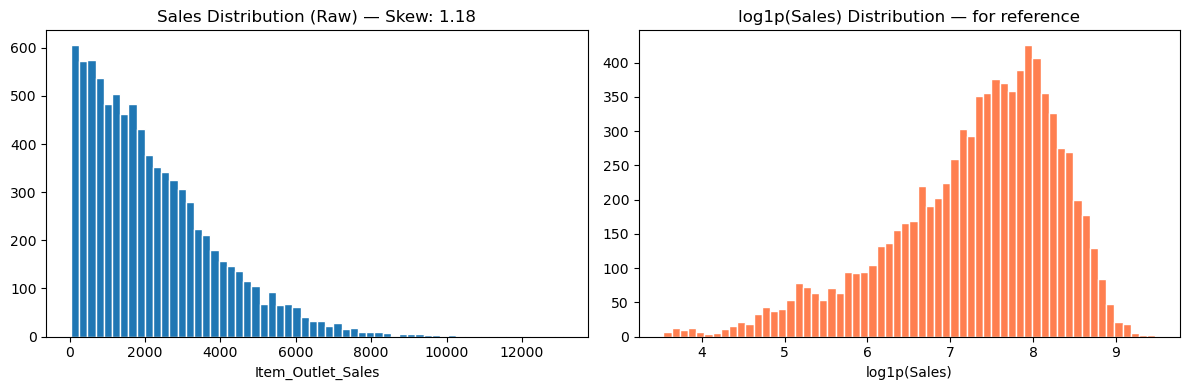

Skewness        : 1.178
Mean Sales      : 2181.3
Median Sales    : 1794.3
Min Sales       : 33.3
Max Sales       : 13087.0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_raw['Item_Outlet_Sales'], bins=60, edgecolor='white')
axes[0].set_title('Sales Distribution (Raw) — Skew: {:.2f}'.format(train_raw['Item_Outlet_Sales'].skew()))
axes[0].set_xlabel('Item_Outlet_Sales')
axes[1].hist(np.log1p(train_raw['Item_Outlet_Sales']), bins=60, edgecolor='white', color='coral')
axes[1].set_title('log1p(Sales) Distribution — for reference')
axes[1].set_xlabel('log1p(Sales)')
plt.tight_layout()
plt.show()

print(f'Skewness        : {train_raw["Item_Outlet_Sales"].skew():.3f}')
print(f'Mean Sales      : {train_raw["Item_Outlet_Sales"].mean():.1f}')
print(f'Median Sales    : {train_raw["Item_Outlet_Sales"].median():.1f}')
print(f'Min Sales       : {train_raw["Item_Outlet_Sales"].min():.1f}')
print(f'Max Sales       : {train_raw["Item_Outlet_Sales"].max():.1f}')

**Inference:** Sales is right-skewed (skew ~1.18) with a long tail of high-selling items. 
Log-transforming brings it closer to normal, but since the competition evaluates on **raw RMSE**, 
training on log transformed sales and back transforming predictions can introduce a systematic bias,
the back-transform from log_Sales to Sales amplifies large errors disproportionately. 

**Decision: Train directly on raw sales.**

### 4.2 — Price (MRP) is the Strongest Driver

Intuitively the `Maximum Retail Price` is the most obvious candidate for the top predictor. Need to verify it

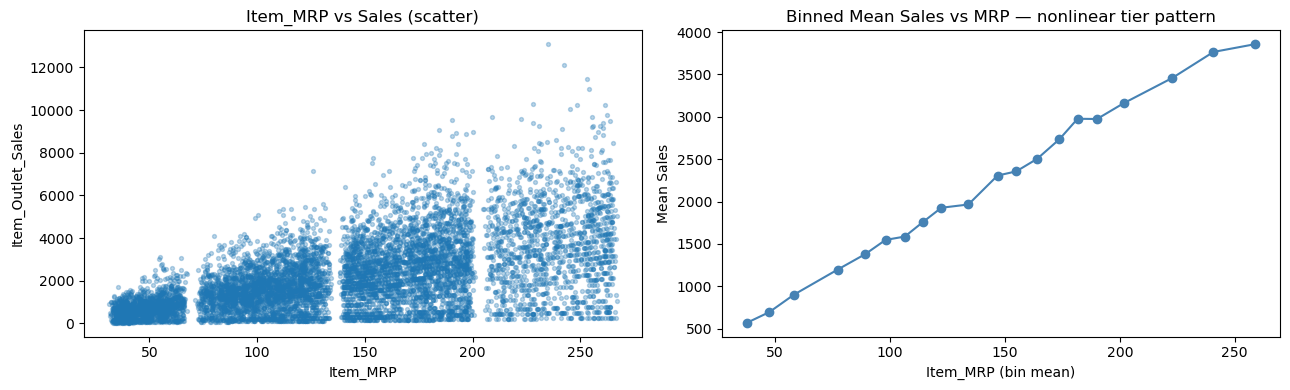

Correlation with Item_Outlet_Sales:
  MRP (raw)    : 0.5676
  MRP squared  : 0.5519
  log(MRP)     : 0.5483


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(train_raw['Item_MRP'], train_raw['Item_Outlet_Sales'], s=8, alpha=0.3)
axes[0].set_title('Item_MRP vs Sales (scatter)')
axes[0].set_xlabel('Item_MRP'); axes[0].set_ylabel('Item_Outlet_Sales')

tmp = train_raw.copy()
tmp['mrp_bin'] = pd.qcut(tmp['Item_MRP'], q=20, duplicates='drop')
binned = tmp.groupby('mrp_bin', observed=True).agg(
    mrp_mean=('Item_MRP','mean'), sales_mean=('Item_Outlet_Sales','mean'))
axes[1].plot(binned['mrp_mean'], binned['sales_mean'], marker='o', color='steelblue')
axes[1].set_title('Binned Mean Sales vs MRP — nonlinear tier pattern')
axes[1].set_xlabel('Item_MRP (bin mean)'); axes[1].set_ylabel('Mean Sales')
plt.tight_layout()
plt.show()

print('Correlation with Item_Outlet_Sales:')
print(f'  MRP (raw)    : {train_raw["Item_MRP"].corr(train_raw["Item_Outlet_Sales"]):.4f}')
print(f'  MRP squared  : {(train_raw["Item_MRP"]**2).corr(train_raw["Item_Outlet_Sales"]):.4f}')
print(f'  log(MRP)     : {np.log(train_raw["Item_MRP"]).corr(train_raw["Item_Outlet_Sales"]):.4f}')

**Inference:** MRP has the strongest linear correlation (~0.57) with sales of any raw feature. 
But the scatter plot and binned trend is revealing more. 
There are visible **step changes** at certain price thresholds. 
This suggests customers are segmenting the products into price buckets (budget, mid-range, premium, luxury), 
and their purchase behaviour changes at those thresholds.

**Decision:** Create both a continuous MRP feature AND a hard categorical `MRP_Tier`. 
At the higher end the price is being increased rapidly hence we included `Item_MRP_Squared`

### 4.3 — Validating Hard Price Tiers

To justify creating a categorical `MRP_Tier` feature, I need to show that hard breakpoints 
exist in the data rather than a smooth curve. The bins below (0–69, 69–136, 136–202, 202+) 
were chosen by examining the distribution of MRP values and looking for natural gaps.

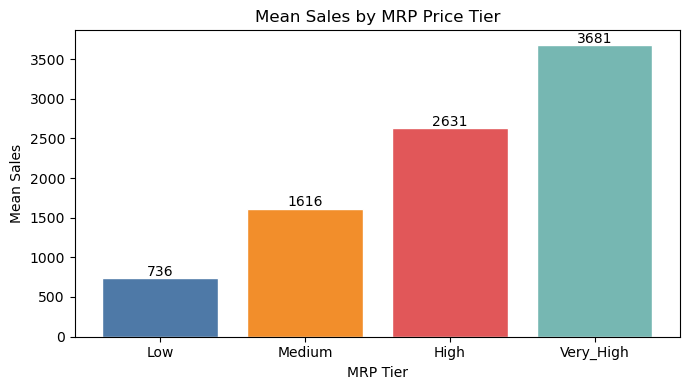

Mean Sales by MRP Tier:
Item_MRP
Low           736.0
Medium       1616.0
High         2631.0
Very_High    3681.0
Name: Item_Outlet_Sales, dtype: float64

Range multiplier (Very_High vs Low): 5.0x


In [6]:
tier_labels = pd.cut(train_raw['Item_MRP'], bins=[0,69,136,202,270],
                     labels=['Low','Medium','High','Very_High'])
tier_sales  = train_raw.groupby(tier_labels, observed=True)['Item_Outlet_Sales'].mean()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(tier_sales.index.astype(str), tier_sales.values,
       color=['#4e79a7','#f28e2b','#e15759','#76b7b2'], edgecolor='white')
for bar, val in zip(bars, tier_sales.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:.0f}', ha='center', fontsize=10)
ax.set_title('Mean Sales by MRP Price Tier')
ax.set_xlabel('MRP Tier'); ax.set_ylabel('Mean Sales')
plt.tight_layout()
plt.show()

print('Mean Sales by MRP Tier:')
print(tier_sales.round(0))
print(f'\nRange multiplier (Very_High vs Low): {tier_sales.max()/tier_sales.min():.1f}x')

**Inference:** The step pattern is clear — mean sales almost **double** at each tier boundary. 
A Very_High tier product sells roughly 3.6x more than a Low tier product on average. 
The high-MRP items are often in categories like household durables or premium food where basket size is inherently larger.

**Decision:** `MRP_Tier` as a string categorical feature. CatBoost will treat each tier as a distinct 
category and learn its effect cleanly, without assuming linearity.

### 4.4 — Outlet Characteristics Drive Structural Differences in Sales

In retail, location and store format are everything. A product's sales in a small grocery store 
will be fundamentally different from the same product in a large supermarket.

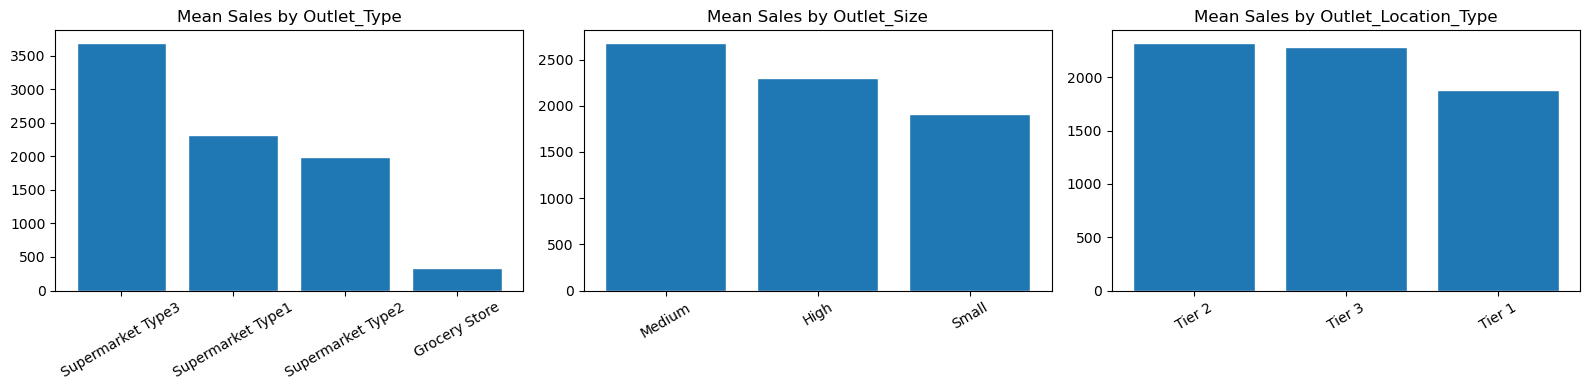

Mean Sales by Outlet_Type:
Outlet_Type
Supermarket Type3    3694.0
Supermarket Type1    2316.0
Supermarket Type2    1995.0
Grocery Store         340.0
Name: Item_Outlet_Sales, dtype: float64

Mean Sales by Outlet_Identifier:
Outlet_Identifier
OUT027    3694.0
OUT035    2439.0
OUT049    2348.0
OUT017    2341.0
OUT013    2299.0
OUT046    2278.0
OUT045    2192.0
OUT018    1995.0
OUT019     340.0
OUT010     339.0
Name: Item_Outlet_Sales, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['Outlet_Type','Outlet_Size','Outlet_Location_Type']):
    g = train_raw.groupby(col)['Item_Outlet_Sales'].mean().sort_values(ascending=False)
    ax.bar(g.index.astype(str), g.values, edgecolor='white')
    ax.set_title(f'Mean Sales by {col}')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print('Mean Sales by Outlet_Type:')
print(train_raw.groupby('Outlet_Type')['Item_Outlet_Sales'].mean().sort_values(ascending=False).round(0))
print('\nMean Sales by Outlet_Identifier:')
print(train_raw.groupby('Outlet_Identifier')['Item_Outlet_Sales'].mean().sort_values(ascending=False).round(0))

**Inference:** 

- **Grocery Stores** (OUT010, OUT019) have mean sales of ~340, roughly **10x lower** than Supermarket Type3 (~3,694)
- It is a kind of categorical regime change
- Even within supermarket types, Type3 significantly outperforms Type1 and Type2

**Decision:** Create an explicit `Is_Grocery_Store` binary flag. Even though `Outlet_Type` is already 
a feature, the binary flag makes this extreme contrast immediately accessible to the tree model. 
Also create `MRP_x_Is_Grocery` because price sensitivity in grocery stores is fundamentally different 
from supermarkets — people buy staples at any price but won't splurge on premium items there.

### 4.5 — How Outlet Age Affects Sales

Older outlets may have built a loyal customer base over time. But they could also be in declining 
neighbourhoods or have outdated infrastructure. we need to look at the actual pattern.

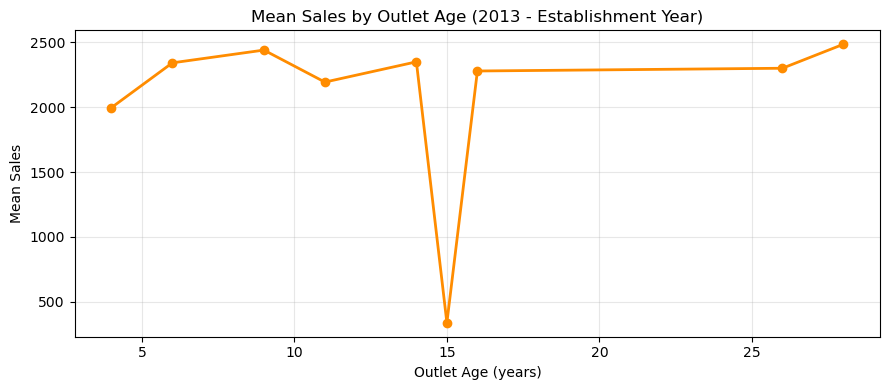

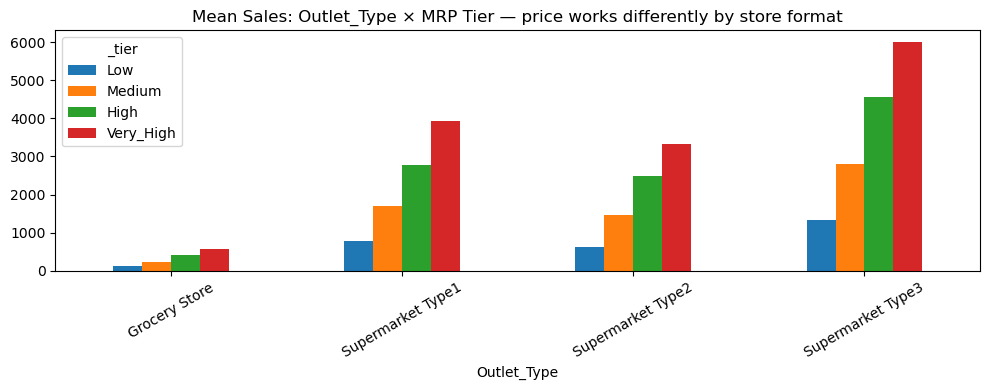

In [8]:
train_raw['_age'] = SALES_YEAR - train_raw['Outlet_Establishment_Year']
age_sales = train_raw.groupby('_age')['Item_Outlet_Sales'].mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(age_sales.index, age_sales.values, marker='o', color='darkorange', linewidth=2)
ax.set_title('Mean Sales by Outlet Age (2013 - Establishment Year)')
ax.set_xlabel('Outlet Age (years)'); ax.set_ylabel('Mean Sales')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Outlet age × type interaction
train_raw['_tier'] = pd.cut(train_raw['Item_MRP'], bins=[0,69,136,202,270],
                             labels=['Low','Medium','High','Very_High'])
pivot = train_raw.groupby(['Outlet_Type','_tier'], observed=True)['Item_Outlet_Sales'].mean().unstack()
fig, ax = plt.subplots(figsize=(10, 4))
pivot.plot(kind='bar', ax=ax)
ax.set_title('Mean Sales: Outlet_Type × MRP Tier — price works differently by store format')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

train_raw.drop(columns=['_age','_tier'], inplace=True, errors='ignore')

**Inference:** The age–sales relationship is **non-monotonic** , it's not that older = better or newer = better. 
The spike at 28 years is driven by OUT027 (Supermarket Type3, the highest performing outlet). 
This means raw age alone is misleading; what matters is the combination of age AND outlet type.

The interaction plot confirms this: Very_High MRP tier items sell dramatically more in Supermarket Type3 
compared to all other formats, while Grocery Stores show almost no price-tier differentiation.

**Decision:** Use `Outlet_Age` as a numeric feature, create `Outlet_Age_Bin` as a categorical version, 
and add `MRP_x_OutletAge` as an interaction. Also create `MRPTier_x_OutletType` and `ItemCat_x_OutletType` 
as string features for CatBoost to learn format specific price effects.

### 4.6 — Visibility:

Intuitively, more visible = more sales. But the data telling another story.

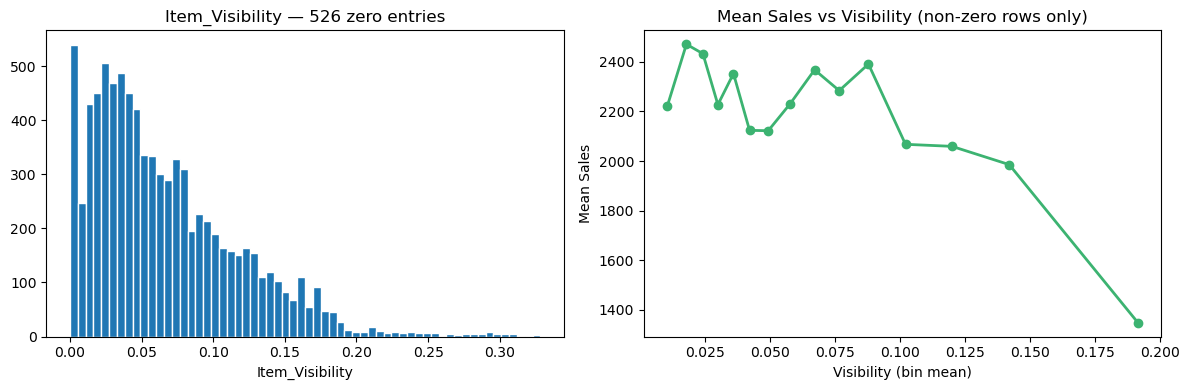

Zero visibility count  : 526
Corr (visibility–sales): -0.1286


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_raw['Item_Visibility'], bins=60, edgecolor='white')
axes[0].set_title(f'Item_Visibility — {(train_raw["Item_Visibility"]==0).sum()} zero entries')
axes[0].set_xlabel('Item_Visibility')

vis_nz = train_raw[train_raw['Item_Visibility'] > 0].copy()
vis_nz['vis_bin'] = pd.qcut(vis_nz['Item_Visibility'], q=15, duplicates='drop')
vb = vis_nz.groupby('vis_bin', observed=True).agg(
    v_mean=('Item_Visibility','mean'), s_mean=('Item_Outlet_Sales','mean'))
axes[1].plot(vb['v_mean'], vb['s_mean'], marker='o', color='mediumseagreen', linewidth=2)
axes[1].set_title('Mean Sales vs Visibility (non-zero rows only)')
axes[1].set_xlabel('Visibility (bin mean)'); axes[1].set_ylabel('Mean Sales')
plt.tight_layout()
plt.show()

print(f'Zero visibility count  : {(train_raw["Item_Visibility"]==0).sum()}')
print(f'Corr (visibility–sales): {train_raw["Item_Visibility"].corr(train_raw["Item_Outlet_Sales"]):.4f}')

**Inference:** Two things stand out:

1. There are **526 rows with zero visibility** in training data. It is physically impossible for a stocked item. 
These are recording errors, not true zeros, and need to be imputed.

2. The binned trend shows a **decreasing relationship** .The higher visibility is associated with lower sales. 
This seems counterintuitive but makes business sense: grocery stores allocate more shelf space to slow-moving 
items trying to push them, whereas fast-movers sell themselves with minimal shelf space.

**Decision:** Impute zeros at the SKU level (not item-type level — each product has its own typical visibility). 
Create a `Visibility_WasZero` flag. Also compute `Visibility_OutletShare` (item's fraction of total store shelf), 
which is more meaningful than the raw value since stores have different total shelf allocations.

### 4.7 — EDA Summary & Feature Engineering Decisions

| Observation | Business Insight | Feature Decision |
|---|---|---|
| Sales is right skewed | Few items dominate revenue | Train on raw sales to match RMSE metric |
| MRP has step function pattern | Customers think in price tiers | `MRP_Tier` (hard breakpoints) + `MRP_Squared` |
| Grocery stores sell 10x less | Store format is a regime change | `Is_Grocery_Store` flag + `MRP_x_Is_Grocery` |
| Outlet age is non monotonic | Format matters more than age alone | `Outlet_Age` + `MRP_x_OutletAge` interaction |
| Price × Format interaction | Same product behaves differently by store | `MRPTier_x_OutletType` cat feature |
| Zero visibility = missing | Recording error, not true zero | SKU-level imputation + `Visibility_WasZero` flag |
| High visibility → lower sales | Stores push slow-movers with shelf space | `Visibility_OutletShare` (normalised) |


## Step 5 — Preprocessing

Train and test are combined before any preprocessing. This is essential fbecause any 
imputation or encoding computed on train only would create a distribution mismatch at inference time. 
**No target leakage risk here** — we are only using X information for imputation.

In [10]:
train_raw['_is_train'] = 1
test_raw['_is_train']  = 0
full_df = pd.concat([train_raw, test_raw], axis=0, ignore_index=True)
print(f'Combined shape: {full_df.shape}')

Combined shape: (14204, 13)


### 5.1 — Cleaning Categorical Labels

The `Item_Fat_Content` column has several inconsistent encodings for the same concept: 
'low fat', 'LF', 'lf' all mean the same thing. Without standardising, the model treats 
these as completely different categories.

Also, `Item_Identifier` starts with a 2-letter code that carries domain meaning: 
FD = Food, DR = Drinks, NC = Non-Consumable. This is an undocumented but highly useful feature.
 Non-Consumables are assigned a separate fat content label ('Non-Edible') since fat content 
is meaningless for household items.

In [11]:
fat_map = {
    'low fat':'Low Fat', 'lf':'Low Fat',     'LF':'Low Fat',
    'reg':'Regular',     'regular':'Regular', 'Regular ':'Regular'
}
full_df['Item_Fat_Content'] = full_df['Item_Fat_Content'].astype(str).str.strip().replace(fat_map)

full_df['Item_Category'] = full_df['Item_Identifier'].str[:2].map(
    {'FD':'Food','DR':'Drinks','NC':'Non-Consumable'}
).fillna('Unknown')
full_df.loc[full_df['Item_Category'] == 'Non-Consumable', 'Item_Fat_Content'] = 'Non-Edible'

print('Item_Fat_Content after cleaning:')
print(full_df['Item_Fat_Content'].value_counts())
print('\nItem_Category distribution:')
print(full_df['Item_Category'].value_counts())

Item_Fat_Content after cleaning:
Item_Fat_Content
Low Fat       6499
Regular       5019
Non-Edible    2686
Name: count, dtype: int64

Item_Category distribution:
Item_Category
Food              10201
Non-Consumable     2686
Drinks             1317
Name: count, dtype: int64


### 5.2 — Missing Value Flags

Before imputing, I create binary flags for each column with missingness. 
This is important because missingness itself carries information. In this dataset, 
missing `Outlet_Size` is not random noise but corresponds to specific outlets that never 
reported size data. The model should be able to learn from this pattern.

In [12]:
full_df['Outlet_Size_WasMissing'] = full_df['Outlet_Size'].isna().astype(int)
full_df['Item_Weight_WasMissing'] = full_df['Item_Weight'].isna().astype(int)
full_df['Visibility_WasZero']     = (full_df['Item_Visibility'] == 0).astype(int)

print('Missing flags created:')
print(full_df[['Outlet_Size_WasMissing','Item_Weight_WasMissing','Visibility_WasZero']].sum())

Missing flags created:
Outlet_Size_WasMissing    4016
Item_Weight_WasMissing    2439
Visibility_WasZero         879
dtype: int64


### 5.3 — Imputing Outlet_Size

The missing `Outlet_Size` entries belong to 3 entire outlets (OUT010, OUT017, OUT045) that never had size data. 
The imputation strategy uses following logic:
1. **Outlet-level mode** — if the outlet has any known size rows, use that
2. **Outlet_Type + Location mode** — for outlets with no size info at all, use the combination of outlet type and location tier.
3. **Overall mode** — For remaining gaps

In [13]:
outlet_size_map = (
    full_df.dropna(subset=['Outlet_Size'])
           .groupby('Outlet_Identifier')['Outlet_Size']
           .agg(lambda s: s.mode().iloc[0])
)
full_df['Outlet_Size'] = full_df['Outlet_Size'].fillna(
    full_df['Outlet_Identifier'].map(outlet_size_map))

type_loc_mode = (
    full_df.dropna(subset=['Outlet_Size'])
           .groupby(['Outlet_Type','Outlet_Location_Type'])['Outlet_Size']
           .agg(lambda s: s.mode().iloc[0])
)
mask = full_df['Outlet_Size'].isna()
full_df.loc[mask, 'Outlet_Size'] = (
    full_df.loc[mask, ['Outlet_Type','Outlet_Location_Type']]
           .apply(lambda r: type_loc_mode.get(
               (r['Outlet_Type'], r['Outlet_Location_Type']), np.nan), axis=1)
)
full_df['Outlet_Size'] = full_df['Outlet_Size'].fillna(full_df['Outlet_Size'].mode().iloc[0])
print(f'Outlet_Size missing after imputation: {full_df["Outlet_Size"].isna().sum()}')
print(full_df['Outlet_Size'].value_counts())

Outlet_Size missing after imputation: 0
Outlet_Size
Small     7996
Medium    4655
High      1553
Name: count, dtype: int64


### 5.4 — Imputing Item_Weight and Item_Visibility

**Item_Weight** is a physical property of the product,it doesn't change between stores. 
So the right approach is to use the same item's known weight from any other row as the imputed value. 
If the item never appears with a weight, use the item-type median.

**Item_Visibility zeros** are imputed at the SKU level — each product has a typical shelf presence. 
Using the item's own median visibility (from non-zero rows) is more accurate than using an 
item-type average, as it would smooth over real product-level differences.

In [14]:
# --- Item_Weight ---
item_weight_map = (
    full_df.dropna(subset=['Item_Weight'])
           .groupby('Item_Identifier')['Item_Weight'].median()
)
full_df['Item_Weight'] = full_df['Item_Weight'].fillna(
    full_df['Item_Identifier'].map(item_weight_map))
itemtype_weight_median = (
    full_df.dropna(subset=['Item_Weight'])
           .groupby('Item_Type')['Item_Weight'].median()
)
mask = full_df['Item_Weight'].isna()
full_df.loc[mask, 'Item_Weight'] = full_df.loc[mask, 'Item_Type'].map(itemtype_weight_median)
full_df['Item_Weight'] = full_df['Item_Weight'].fillna(full_df['Item_Weight'].median())

# --- Item_Visibility zeros (SKU-level imputation) ---
item_vis_map = (
    full_df[full_df['Item_Visibility'] > 0]
           .groupby('Item_Identifier')['Item_Visibility'].median()
)
mask_zero = (full_df['Item_Visibility'] == 0)
full_df.loc[mask_zero, 'Item_Visibility'] = (
    full_df.loc[mask_zero, 'Item_Identifier'].map(item_vis_map))
itemtype_vis_median = (
    full_df[full_df['Item_Visibility'] > 0]
           .groupby('Item_Type')['Item_Visibility'].median()
)
mask_still = full_df['Item_Visibility'].isna() | (full_df['Item_Visibility'] == 0)
full_df.loc[mask_still, 'Item_Visibility'] = (
    full_df.loc[mask_still, 'Item_Type'].map(itemtype_vis_median))
full_df['Item_Visibility'] = full_df['Item_Visibility'].fillna(full_df['Item_Visibility'].median())

print(f'Item_Weight missing : {full_df["Item_Weight"].isna().sum()}')
print(f'Visibility zeros    : {(full_df["Item_Visibility"] == 0).sum()}')
print(f'Any remaining NaN   : {full_df[["Item_Weight","Item_Visibility","Outlet_Size"]].isna().any().any()}')

Item_Weight missing : 0
Visibility zeros    : 0
Any remaining NaN   : False


## Step 6 — Feature Engineering


All features are computed on the combined train+test dataframe to ensure identical encoding across both sets.

### 6.1 — Outlet Maturity & Price Positioning Features

**Outlet_Age** converts the establishment year into years of operation. Older stores have deeper customer relationships, 
better staff, and more optimised product placement. But raw age interacts strongly with store format, so we also create `MRP_x_OutletAge`.

**MRP features** capture how a product is priced *relative to its category and relative to its store*. 
A ₹200 item might be cheap in a premium category but expensive in a budget category — 
the ratio tells us this, the raw value doesn't.

In [29]:
# Outlet Age
full_df['Outlet_Age'] = SALES_YEAR - full_df['Outlet_Establishment_Year']

# MRP quantile bins — soft segmentation
full_df['MRP_Bin']  = pd.qcut(full_df['Item_MRP'], q=4, labels=False, duplicates='drop').astype(float)
full_df['MRP_Bin8'] = pd.qcut(full_df['Item_MRP'], q=8, labels=False, duplicates='drop').astype(float)

# Relative MRP within item type — premium vs budget within same category
itemtype_mrp_mean = full_df.groupby('Item_Type')['Item_MRP'].transform('mean')
itemtype_mrp_std  = full_df.groupby('Item_Type')['Item_MRP'].transform('std').replace(0,1)
full_df['MRP_Ratio_ItemTypeMean']   = full_df['Item_MRP'] / itemtype_mrp_mean
full_df['Item_MRP_zscore_ItemType'] = (full_df['Item_MRP'] - itemtype_mrp_mean) / itemtype_mrp_std
full_df['MRP_RankPct_ItemType']     = full_df.groupby('Item_Type')['Item_MRP'].transform(lambda x: x.rank(pct=True))

# Relative MRP within outlet — is this item expensive for this store?
outlet_mrp_mean = full_df.groupby('Outlet_Identifier')['Item_MRP'].transform('mean')
outlet_mrp_std  = full_df.groupby('Outlet_Identifier')['Item_MRP'].transform('std').replace(0,1)
full_df['MRP_Ratio_OutletMean']      = full_df['Item_MRP'] / outlet_mrp_mean
full_df['Item_MRP_minus_OutletMean'] = full_df['Item_MRP'] - outlet_mrp_mean
full_df['Outlet_MRP_Mean']           = outlet_mrp_mean
full_df['Outlet_MRP_Std']            = outlet_mrp_std

# Interactions
full_df['MRP_x_OutletAge'] = full_df['Item_MRP'] * full_df['Outlet_Age']

print('MRP and outlet age features created.')
full_df[['MRP_Ratio_ItemTypeMean','Item_MRP_zscore_ItemType','MRP_RankPct_ItemType','Outlet_Age']].describe().round(3)

MRP and outlet age features created.


,MRP_Ratio_ItemTypeMean,Item_MRP_zscore_ItemType,MRP_RankPct_ItemType,Outlet_Age
count,14204.000,14204.000,14204.000,14204.000
mean,1.000,0.000,0.501,15.169
std,0.439,0.999,0.289,8.372
min,0.215,-1.916,0.000,4.000
25%,0.668,-0.755,0.251,9.000
50%,1.000,-0.000,0.500,14.000
75%,1.317,0.733,0.751,26.000
max,2.083,2.410,1.000,28.000


### 6.2 — Visibility Features

Raw visibility has two problems: it's right skewed, and it's not normalised across stores 
(a visibility of 0.05 means something different in a large store vs a small one). 


- `Item_Visibility_log1p`: reduces the right skew
- `Item_Visibility_capped`: caps outliers at the 95th percentile
- `Visibility_OutletShare`: the item's share of total shelf in its store — this is the truly comparable measure
- `Visibility_Ratio_ItemTypeMean`: how visible is this product relative to others in its category

In [16]:
full_df['Item_Visibility_log1p']  = np.log1p(full_df['Item_Visibility'])
vis_cap = full_df['Item_Visibility'].quantile(0.95)
full_df['Item_Visibility_capped'] = full_df['Item_Visibility'].clip(upper=vis_cap)

itemtype_vis_mean  = full_df.groupby('Item_Type')['Item_Visibility'].transform('mean')
outlet_vis_mean    = full_df.groupby('Outlet_Identifier')['Item_Visibility'].transform('mean')
full_df['Visibility_Ratio_ItemTypeMean']    = full_df['Item_Visibility'] / itemtype_vis_mean
full_df['Visibility_Ratio_OutletMean']      = full_df['Item_Visibility'] / outlet_vis_mean
full_df['Item_Visibility_minus_OutletMean'] = full_df['Item_Visibility'] - outlet_vis_mean
full_df['Outlet_Visibility_Mean']           = outlet_vis_mean
full_df['Item_Visibility_per_Weight']       = full_df['Item_Visibility'] / (full_df['Item_Weight'] + 1e-6)

# Outlet share — item's fraction of total shelf space in its store
outlet_total_vis = full_df.groupby('Outlet_Identifier')['Item_Visibility'].transform('sum')
full_df['Visibility_OutletShare'] = full_df['Item_Visibility'] / outlet_total_vis

full_df['Visibility_x_MRP']        = full_df['Item_Visibility'] * full_df['Item_MRP']
full_df['Visibility_x_Outlet_Age'] = full_df['Item_Visibility'] * full_df['Outlet_Age']

print('Visibility features created.')

Visibility features created.


### 6.3 — Item Weight, Store Breadth & Interaction Features

**Item_Weight_zscore_ItemType** tells if this product unusually heavy or light for its category? 
Heavy items might have higher MRP and signal premium quality.

**Outlet assortment breadth** (unique items, unique types, total count) is a proxy for store scale. 
A store with 1,500 unique SKUs is fundamentally different from one with 500. the former likely 
has more footfall, better logistics, and higher revenue per item.

In [ ]:
# Weight z-score within item type
itemtype_weight_mean = full_df.groupby('Item_Type')['Item_Weight'].transform('mean')
itemtype_weight_std  = full_df.groupby('Item_Type')['Item_Weight'].transform('std').replace(0,1)
full_df['Item_Weight_zscore_ItemType'] = (full_df['Item_Weight'] - itemtype_weight_mean) / itemtype_weight_std

# Outlet assortment breadth- proxy for store scale
full_df['Outlet_Unique_Items']     = full_df.groupby('Outlet_Identifier')['Item_Identifier'].transform('nunique')
full_df['Outlet_Unique_ItemTypes'] = full_df.groupby('Outlet_Identifier')['Item_Type'].transform('nunique')
full_df['Outlet_Item_Count']       = full_df.groupby('Outlet_Identifier')['Item_Identifier'].transform('count')
full_df['Item_Outlet_Count']       = full_df.groupby('Item_Identifier')['Outlet_Identifier'].transform('count')

# Interactions
full_df['MRP_x_Outlet_Unique_Items'] = full_df['Item_MRP'] * full_df['Outlet_Unique_Items']

# Bin features
full_df['Weight_Bin'] = pd.qcut(full_df['Item_Weight'], q=5, labels=False, duplicates='drop').astype(float)
full_df['Outlet_Age_Bin'] = pd.cut(
    full_df['Outlet_Age'], bins=[0,5,10,15,20,100],
    labels=['0-5','5-10','10-15','15-20','20+']
).astype(str)

print('Weight and breadth features created.')
print(f'Outlet_Unique_Items range: {full_df["Outlet_Unique_Items"].min()} – {full_df["Outlet_Unique_Items"].max()}')

Weight and breadth features created.
Outlet_Unique_Items range: 880 – 1559


### 6.4 —New Features 

These features were added after initial modelling showed a mediocre RMSE 
Each one targets a specific gap identified in the EDA:

- **MRP_Tier**: Hard categorical tiers outperform soft quantile bins for the step-function price pattern
- **Item_MRP_Squared**: Captures the accelerating effect of price at the premium end
- **Is_Grocery_Store**: Explicit flag for the 10x sales gap between grocery and supermarket formats
- **MRP_x_Is_Grocery**: In grocery stores, price barely affects sales; in supermarkets, it's everything
- **ItemCat_x_OutletType** and **MRPTier_x_OutletType**: String interaction features that CatBoost handles natively as new categorical combinations

In [18]:
# Hard MRP tiers — breakpoints from EDA
full_df['MRP_Tier'] = pd.cut(
    full_df['Item_MRP'], bins=[0, 69, 136, 202, 1000],
    labels=['Low','Medium','High','Very_High']
).astype(str)

# MRP squared — super-linear price effect
full_df['Item_MRP_Squared'] = full_df['Item_MRP'] ** 2

# Grocery store flag and price interaction
full_df['Is_Grocery_Store'] = (full_df['Outlet_Type'] == 'Grocery Store').astype(int)
full_df['MRP_x_Is_Grocery'] = full_df['Item_MRP'] * full_df['Is_Grocery_Store']

# String interaction features for CatBoost native handling
full_df['ItemCat_x_OutletType']  = full_df['Item_Category'].astype(str) + '_' + full_df['Outlet_Type'].astype(str)
full_df['MRPTier_x_OutletType']  = full_df['MRP_Tier'].astype(str) + '_' + full_df['Outlet_Type'].astype(str)

print(f'Feature engineering complete.')
print(f'Total columns in full_df: {full_df.shape[1]}')
engineered = [c for c in full_df.columns if c not in train_raw.columns and c not in test_raw.columns]
print(f'Engineered features ({len(engineered)}): {engineered}')

Feature engineering complete.
Total columns in full_df: 52
Engineered features (39): ['Item_Category', 'Outlet_Size_WasMissing', 'Item_Weight_WasMissing', 'Visibility_WasZero', 'Outlet_Age', 'MRP_Bin', 'MRP_Bin8', 'MRP_Ratio_ItemTypeMean', 'Item_MRP_zscore_ItemType', 'MRP_RankPct_ItemType', 'MRP_Ratio_OutletMean', 'Item_MRP_minus_OutletMean', 'Outlet_MRP_Mean', 'Outlet_MRP_Std', 'MRP_x_OutletAge', 'Item_Visibility_log1p', 'Item_Visibility_capped', 'Visibility_Ratio_ItemTypeMean', 'Visibility_Ratio_OutletMean', 'Item_Visibility_minus_OutletMean', 'Outlet_Visibility_Mean', 'Item_Visibility_per_Weight', 'Visibility_OutletShare', 'Visibility_x_MRP', 'Visibility_x_Outlet_Age', 'Item_Weight_zscore_ItemType', 'Outlet_Unique_Items', 'Outlet_Unique_ItemTypes', 'Outlet_Item_Count', 'Item_Outlet_Count', 'MRP_x_Outlet_Unique_Items', 'Weight_Bin', 'Outlet_Age_Bin', 'MRP_Tier', 'Item_MRP_Squared', 'Is_Grocery_Store', 'MRP_x_Is_Grocery', 'ItemCat_x_OutletType', 'MRPTier_x_OutletType']


## Step 7 — Prepare Model Inputs


In [19]:
train_mask = full_df['_is_train'] == 1
test_mask  = full_df['_is_train'] == 0

processed_train = full_df[train_mask].copy()
processed_test  = full_df[test_mask].copy()

# RAW sales — no log transform (matches leaderboard RMSE directly)
y = processed_train['Item_Outlet_Sales'].values.astype(float)

drop_cols = ['Item_Outlet_Sales', '_is_train', 'Outlet_Establishment_Year']
X      = processed_train.drop(columns=[c for c in drop_cols if c in processed_train.columns])
X_test = processed_test[X.columns].copy()

cat_features_cb = X.select_dtypes(include=['object','category']).columns.tolist()

print(f'Training set shape    : {X.shape}')
print(f'Test set shape        : {X_test.shape}')
print(f'Numeric features      : {X.select_dtypes(include=["int64","float64"]).shape[1]}')
print(f'Categorical features  : {len(cat_features_cb)}')
print(f'Cat features          : {cat_features_cb}')
print(f'\nTarget stats:')
print(f'  mean={y.mean():.1f}, std={y.std():.1f}, min={y.min():.1f}, max={y.max():.1f}')

assert X.isna().sum().sum() == 0, 'NaN found in X'
assert X_test.isna().sum().sum() == 0, 'NaN found in X_test'
print('\nNo missing values in feature matrices ✓')

Training set shape    : (8523, 49)
Test set shape        : (5681, 49)
Numeric features      : 37
Categorical features  : 12
Cat features          : ['Outlet_Identifier', 'Item_Identifier', 'Outlet_Location_Type', 'Outlet_Type', 'Outlet_Size', 'Item_Type', 'Item_Fat_Content', 'Item_Category', 'Outlet_Age_Bin', 'MRP_Tier', 'ItemCat_x_OutletType', 'MRPTier_x_OutletType']

Target stats:
  mean=2181.3, std=1706.4, min=33.3, max=13087.0

No missing values in feature matrices ✓


## Step 8 — Hyperparameter Tuning with Optuna

CatBoost has several parameters that 
interact in non-obvious ways, tuning them together with a smart search strategy finds combinations 
that wouldn't be found by individual parameter sweeps.

**Why Optuna over GridSearch?**
Optuna uses a Tree structured Parzen Estimator (TPE) which learns from previous trials. it focuses 
the search on promising regions of the parameter space rather than exhaustively trying everything. 

**Parameters being tuned:**
- `learning_rate`: controls step size
- `depth`: tree depth — deeper trees capture more interactions but overfit more easily
- `l2_leaf_reg`: L2 regularisation — higher reduces overfitting
- `subsample` & `colsample_bylevel`: random subsampling — improves generalisation
- `min_data_in_leaf`: minimum observations per leaf — prevents fitting on noise
- `bagging_temperature`: controls stochasticity in bootstrap sampling


In [20]:
def objective(trial):
    params = {
        'loss_function'      : 'RMSE',
        'eval_metric'        : 'RMSE',
        'iterations'         : 3000,
        'learning_rate'      : trial.suggest_float('learning_rate',      0.03, 0.15, log=True),
        'depth'              : trial.suggest_int(  'depth',               6,   10),
        'l2_leaf_reg'        : trial.suggest_float('l2_leaf_reg',         1,   10,  log=True),
        'subsample'          : trial.suggest_float('subsample',           0.6,  1.0),
        'colsample_bylevel'  : trial.suggest_float('colsample_bylevel',   0.6,  1.0),
        'min_data_in_leaf'   : trial.suggest_int(  'min_data_in_leaf',    1,   50),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0,  1.0),
        'random_seed'        : RANDOM_SEED,
        'od_type'            : 'Iter',
        'od_wait'            : 100,
        'verbose'            : 0,
        'allow_writing_files': False,
    }
    kf_opt = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    scores = []
    for tr_idx, val_idx in kf_opt.split(X):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y[tr_idx],      y[val_idx]
        model = CatBoostRegressor(**params)
        model.fit(
            Pool(X_tr,  y_tr,  cat_features=cat_features_cb),
            eval_set=Pool(X_val, y_val, cat_features=cat_features_cb),
            early_stopping_rounds=100,
        )
        scores.append(np.sqrt(mean_squared_error(y_val, model.predict(X_val))))
    return np.mean(scores)

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nBest CV RMSE : {study.best_value:.2f}')
print('Best params  :')
for k, v in study.best_params.items():
    print(f'  {k:25s}: {v}')

  0%|          | 0/50 [00:00<?, ?it/s]


Best CV RMSE : 1075.09
Best params  :
  learning_rate            : 0.08636207589799991
  depth                    : 7
  l2_leaf_reg              : 1.8583959112032944
  subsample                : 0.7473748504742239
  colsample_bylevel        : 0.7634387341241804
  min_data_in_leaf         : 50
  bagging_temperature      : 0.4621402225682101


### 8.1 — Tuning Results Visualisation

The plots below show how the search converged. The left panel shows all 50 trial scores; 
the right shows the running best.

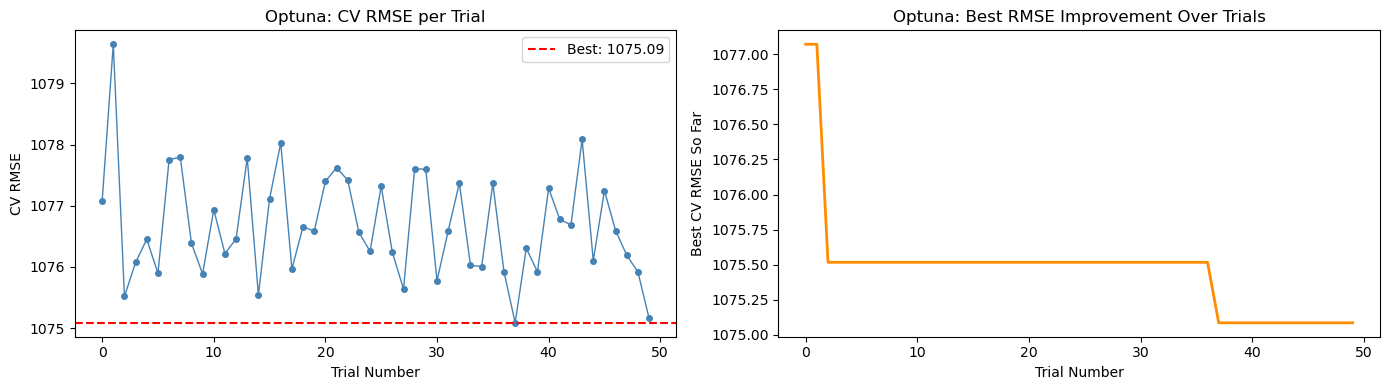

In [21]:
trial_values = [t.value for t in study.trials if t.value is not None]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(trial_values, marker='o', markersize=4, linewidth=1, color='steelblue')
axes[0].axhline(y=study.best_value, color='red', linestyle='--',
                label=f'Best: {study.best_value:.2f}')
axes[0].set_title('Optuna: CV RMSE per Trial')
axes[0].set_xlabel('Trial Number'); axes[0].set_ylabel('CV RMSE')
axes[0].legend()

running_best = pd.Series(trial_values).cummin()
axes[1].plot(running_best, color='darkorange', linewidth=2)
axes[1].set_title('Optuna: Best RMSE Improvement Over Trials')
axes[1].set_xlabel('Trial Number'); axes[1].set_ylabel('Best CV RMSE So Far')
plt.tight_layout()
plt.show()

## Step 9 — Final Model Training

With the best hyperparameters identified, the final CatBoost model is trained using 5 fold cross validation. 
This serves two purposes:
1. **Robust CV score** — averaging across 5 folds gives a more stable RMSE estimate than a single train/val split
2. **Averaged test predictions** — each fold's model predicts on the test set; the average of these 5 predictions 
is more stable than a single model prediction

The final model is then retrained on the full training set using the average best iteration

In [22]:
best = study.best_params
cat_params = {
    'loss_function'      : 'RMSE',
    'eval_metric'        : 'RMSE',
    'iterations'         : 5000,
    'learning_rate'      : best['learning_rate'],
    'depth'              : best['depth'],
    'l2_leaf_reg'        : best['l2_leaf_reg'],
    'subsample'          : best['subsample'],
    'colsample_bylevel'  : best['colsample_bylevel'],
    'min_data_in_leaf'   : best['min_data_in_leaf'],
    'bagging_temperature': best['bagging_temperature'],
    'random_seed'        : RANDOM_SEED,
    'od_type'            : 'Iter',
    'od_wait'            : 200,
    'verbose'            : 200,
    'allow_writing_files': False,
}

kf         = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
rmse_folds = []
best_iters = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y[tr_idx],      y[val_idx]

    train_pool = Pool(X_tr,  y_tr,  cat_features=cat_features_cb)
    val_pool   = Pool(X_val, y_val, cat_features=cat_features_cb)

    cb_model = CatBoostRegressor(**cat_params)
    cb_model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=200)

    val_pred           = cb_model.predict(X_val)
    oof_preds[val_idx] = val_pred
    fold_rmse          = np.sqrt(mean_squared_error(y_val, val_pred))
    rmse_folds.append(fold_rmse)
    best_iters.append(cb_model.best_iteration_)
    test_preds += cb_model.predict(X_test) / N_FOLDS

    print(f'Fold {fold}: RMSE = {fold_rmse:.2f} | best_iter = {cb_model.best_iteration_}')

print(f'\nCV RMSE : {np.mean(rmse_folds):.2f} ± {np.std(rmse_folds):.2f}')

0:	learn: 1636.2825320	test: 1567.7388089	best: 1567.7388089 (0)	total: 11.4ms	remaining: 56.9s
200:	learn: 957.9139495	test: 1028.0523266	best: 1017.3421285 (46)	total: 2.62s	remaining: 1m 2s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 1017.342129
bestIteration = 46

Shrink model to first 47 iterations.
Fold 1: RMSE = 1017.34 | best_iter = 46
0:	learn: 1626.0672423	test: 1611.1516697	best: 1611.1516697 (0)	total: 8.36ms	remaining: 41.8s
200:	learn: 959.4328205	test: 1076.5177595	best: 1072.6426309 (163)	total: 2.62s	remaining: 1m 2s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 1072.642631
bestIteration = 163

Shrink model to first 164 iterations.
Fold 2: RMSE = 1072.64 | best_iter = 163
0:	learn: 1627.2930239	test: 1625.6984219	best: 1625.6984219 (0)	total: 7.92ms	remaining: 39.6s
200:	learn: 945.0080996	test: 1066.6897786	best: 1059.7770602 (79)	total: 2.7s	remaining: 1m 4s
Stopped by overfitting detector  (200 iterations wait)

bestTest =

In [23]:
# Refit on full training data
best_iter_final  = int(np.mean(best_iters) * 1.05)
cat_params_final = {**cat_params, 'iterations': best_iter_final, 'od_wait': 99999, 'verbose': 500}
final_cb = CatBoostRegressor(**cat_params_final)
final_cb.fit(Pool(X, y, cat_features=cat_features_cb))
print(f'Final model trained on full data — {best_iter_final} iterations')

0:	learn: 1621.5847852	total: 5.28ms	remaining: 459ms
87:	learn: 1030.7248813	total: 525ms	remaining: 0us
Final model trained on full data — 88 iterations


## Step 10 — Feature Importance

CatBoost's `PredictionValuesChange` importance measures how much the model's predictions change when a feature's 
values are changed. Features with high importance are the ones driving the most prediction variance.


Top 30 features by importance:
                      feature  importance
         MRPTier_x_OutletType   35.518350
    MRP_x_Outlet_Unique_Items    6.972799
            Outlet_Identifier    6.443880
         ItemCat_x_OutletType    5.957923
                  Outlet_Type    4.658425
             Item_MRP_Squared    3.988022
                     MRP_Tier    3.855585
                     Item_MRP    2.971509
       MRP_Ratio_ItemTypeMean    2.533998
     Item_MRP_zscore_ItemType    2.315048
              MRP_x_OutletAge    2.195546
       Item_Weight_WasMissing    1.696981
                      MRP_Bin    1.562532
       Outlet_Visibility_Mean    1.557137
                    Item_Type    1.476176
               Outlet_MRP_Std    1.399519
    Item_MRP_minus_OutletMean    1.319561
               Outlet_Age_Bin    1.231481
                     MRP_Bin8    0.930199
         MRP_RankPct_ItemType    0.820111
            Item_Outlet_Count    0.711872
                   Outlet_Age    0.662596
   

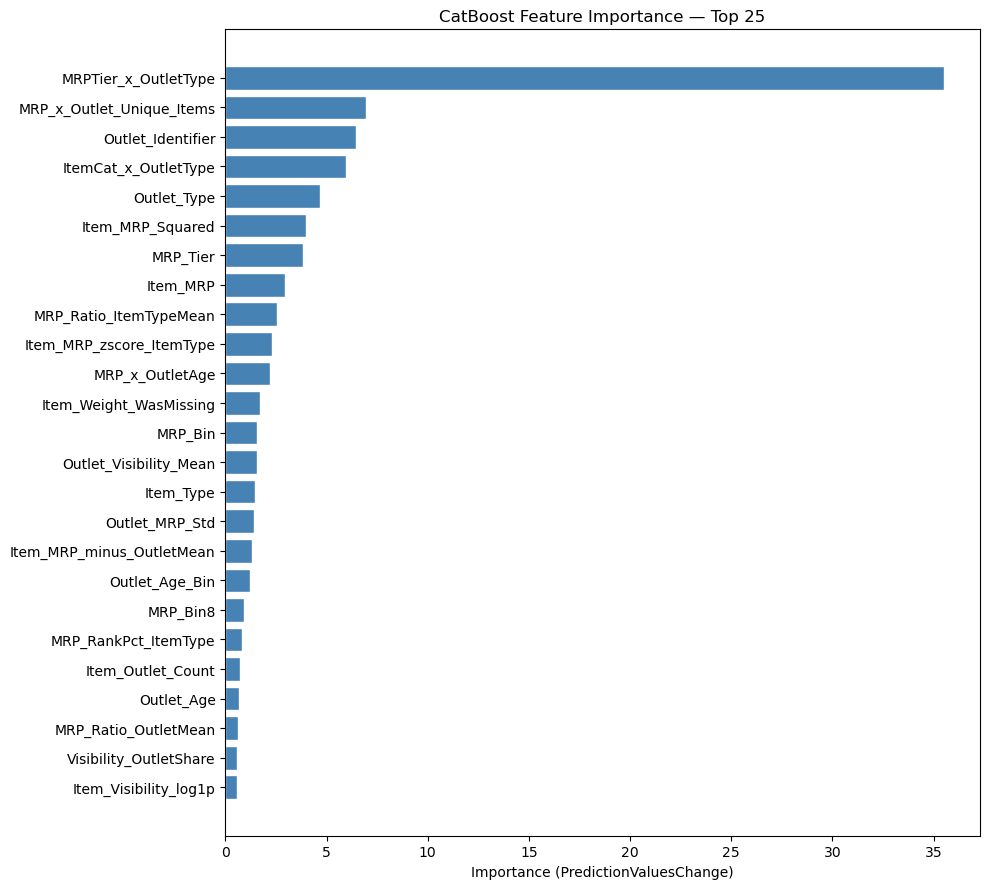

In [24]:
importances = final_cb.get_feature_importance(type='PredictionValuesChange')
fi = pd.DataFrame({'feature': X.columns, 'importance': importances})
fi = fi.sort_values('importance', ascending=False).reset_index(drop=True)

print('Top 30 features by importance:')
print(fi.head(30).to_string(index=False))

top_n  = 25
fi_top = fi.head(top_n).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(fi_top['feature'], fi_top['importance'], color='steelblue', edgecolor='white')
ax.set_title(f'CatBoost Feature Importance — Top {top_n}')
ax.set_xlabel('Importance (PredictionValuesChange)')
plt.tight_layout()
plt.show()

## Step 11 —Prediction Analysis

OOF RMSE (combined): 1075.68
Residual mean      : 1.94
Residual std       : 1075.67


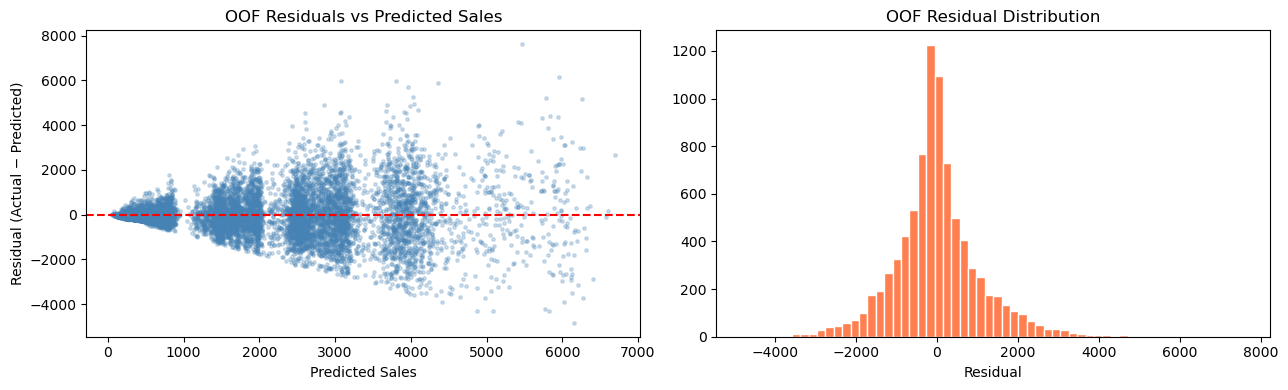

In [25]:
oof_rmse  = np.sqrt(mean_squared_error(y, oof_preds))
residuals = y - oof_preds

print(f'OOF RMSE (combined): {oof_rmse:.2f}')
print(f'Residual mean      : {residuals.mean():.2f}')
print(f'Residual std       : {residuals.std():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(oof_preds, residuals, s=6, alpha=0.25, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('OOF Residuals vs Predicted Sales')
axes[0].set_xlabel('Predicted Sales'); axes[0].set_ylabel('Residual (Actual − Predicted)')

axes[1].hist(residuals, bins=60, edgecolor='white', color='coral')
axes[1].set_title(f'OOF Residual Distribution')
axes[1].set_xlabel('Residual')
plt.tight_layout()
plt.show()

## Step 12 — Generate Submission File

Predictions are clipped at the minimum observed training sales value (33.29) to prevent negative values — 
the competition portal rejects files with negative sales predictions.

In [26]:
MIN_SALES  = float(train_raw['Item_Outlet_Sales'].min())
test_preds_clipped = np.clip(test_preds, a_min=MIN_SALES, a_max=None)

submission = processed_test[['Item_Identifier','Outlet_Identifier']].copy()
submission['Item_Outlet_Sales'] = test_preds_clipped

submission_path = '/Users/bujji/Documents/Mumbai/Case_analytics_vidhya_ABB/submission_CatBoost_optuna.csv'
submission.to_csv(submission_path, index=False)

print(f'Submission saved to : {submission_path}')
print(f'Shape               : {submission.shape}')
print(f'Negative values     : {(test_preds_clipped < 0).sum()} (all clipped to {MIN_SALES:.2f})')
print(f'\nPrediction stats:')
print(f'  mean = {test_preds_clipped.mean():.1f}')
print(f'  std  = {test_preds_clipped.std():.1f}')
print(f'  min  = {test_preds_clipped.min():.1f}')
print(f'  max  = {test_preds_clipped.max():.1f}')
print()
submission.head(10)

Submission saved to : /Users/bujji/Documents/Mumbai/Case_analytics_vidhya_ABB/submission_CatBoost_optuna.csv
Shape               : (5681, 3)
Negative values     : 0 (all clipped to 33.29)

Prediction stats:
  mean = 2178.0
  std  = 1311.3
  min  = 122.4
  max  = 6256.8



,Item_Identifier,Outlet_Identifier,Item_Outlet_Sales
8523,FDW58,OUT049,1720.178851
8524,FDW14,OUT017,1470.494200
8525,NCN55,OUT010,630.411371
8526,FDQ58,OUT017,2563.293125
8527,FDY38,OUT027,5889.436980
8528,FDH56,OUT046,1892.784793
8529,FDL48,OUT018,628.151164
8530,FDC48,OUT027,2392.004358
8531,FDN33,OUT045,1539.992949
8532,FDA36,OUT017,3143.481461


## Summary

| Stage | Detail |
|---|---|
| Dataset | 8,523 train / 5,681 test records across 10 outlets |
| Target | Raw `Item_Outlet_Sales` (no log transform) |
| Missing values | `Outlet_Size`: outlet-mode fallback · `Item_Weight`: SKU-level median · `Visibility`: SKU-level median |
| Features engineered | 40+ features across price positioning, visibility normalisation, outlet scale, and format interactions |
| Model | CatBoost Regressor with native categorical handling |
| Tuning | Optuna TPE sampler, 50 trials, 5-fold CV per trial |
| Validation | 5-fold CV, OOF averaging for test predictions |
| Submission | Clipped at min observed training sales (33.29) |


In [27]:
summary_df = pd.DataFrame({
    'Fold'     : list(range(1, N_FOLDS+1)),
    'RMSE'     : [round(r, 2) for r in rmse_folds],
    'Best_Iter': best_iters,
})
print(summary_df.to_string(index=False))
print(f'\nOptuna best CV RMSE : {study.best_value:.2f}')
print(f'Final CV RMSE       : {np.mean(rmse_folds):.2f} ± {np.std(rmse_folds):.2f}')
print(f'\nBest hyperparameters found:')
for k, v in study.best_params.items():
    print(f'  {k:25s}: {round(v,5) if isinstance(v,float) else v}')

 Fold    RMSE  Best_Iter
    1 1017.34         46
    2 1072.64        163
    3 1059.78         79
    4 1111.03         71
    5 1114.64         61

Optuna best CV RMSE : 1075.09
Final CV RMSE       : 1075.09 ± 35.86

Best hyperparameters found:
  learning_rate            : 0.08636
  depth                    : 7
  l2_leaf_reg              : 1.8584
  subsample                : 0.74737
  colsample_bylevel        : 0.76344
  min_data_in_leaf         : 50
  bagging_temperature      : 0.46214


## Models that we have used before the final model selection

##### Initially we used Ridge Regression for the explainability , but because of the heavy non-Linear nature in the Data and lower RMSE,  we shifted to Tree based models where we have chosen CATBoost as we have more number of categorical features